In [ ]:
import altair as alt
import marimo as mo
import pandas as pd

# Hyperparameter tuning for Multimodal Transformers for Humor Recognition

In [ ]:
_models_names = {
    'bert-base-portuguese-cased': 'BERTimbau-base',
    'bert-large-portuguese-cased': 'BERTimbau-large',
    'albertina-900m-portuguese-ptbr-encoder': 'Albertina-900M-PT-BR',
    'albertina-900m-portuguese-ptpt-encoder': 'Albertina-900M-PT-PT'
}
_methods_formulas = {
    'base': 'x',
    'concatenation': 'x‖v',
    'pooling': 'x‖f(v)',
    'shared': 'f(x‖f(v))'
}
models_order = ['Albertina-900M-PT-BR', 'Albertina-900M-PT-PT', 'BERTimbau-large', 'BERTimbau-base']
methods_order = ['x', 'x‖v', 'x‖f(v)', 'f(x‖f(v))']
# methods_order = ['concatenation', 'pooling', 'shared']

sweeps_df = pd.read_parquet('results/sweeps/sweeps.parquet')
sweeps_df['model'] = sweeps_df['model'].replace(_models_names)
sweeps_df['method'] = sweeps_df['method'].replace(_methods_formulas)
sweeps_df['model'] = pd.Categorical(sweeps_df['model'], categories=models_order, ordered=True)
sweeps_df['method'] = pd.Categorical(sweeps_df['method'], categories=methods_order, ordered=True)
runs_df = pd.read_parquet('results/sweeps/runs.parquet')
history_df = pd.read_parquet('results/sweeps/history.parquet')
best_df = (
    history_df.dropna(subset=['eval/f1_macro'])
    .groupby('run name', as_index=False)['eval/f1_macro'].max()
)
summary_df = best_df.merge(runs_df, on='run name').merge(sweeps_df, on='sweep id')

In [ ]:
@alt.theme.register("custom_theme", enable=True)
def black_marks() -> alt.theme.ThemeConfig:
    return {
        "config": {
            "view": {"stroke": None},
            "axis": {"labelFontSize": 11, "titleFontSize": 12},
            "legend": {"labelFontSize": 11, "titleFontSize": 12},
            "header": {"labelFontSize": 11, "titleFontSize": 12}
        }
    }


## Best models

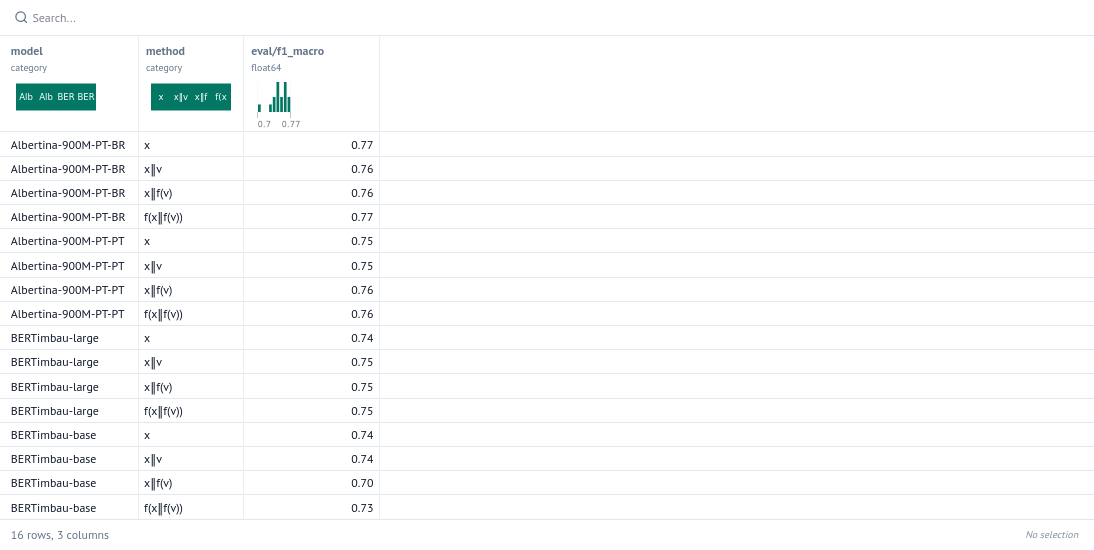

In [ ]:
mo.ui.table(
    (
        summary_df.groupby(['model', 'method'], as_index=False, observed=True)['eval/f1_macro'].max()
        [['model', 'method', 'eval/f1_macro']]
        .sort_values(by=['model', 'method'])
        .reset_index(drop=True)
    ),
    selection=None,
    pagination=False,
    format_mapping={
        'eval/f1_macro': '{:.2f}'
    }
)

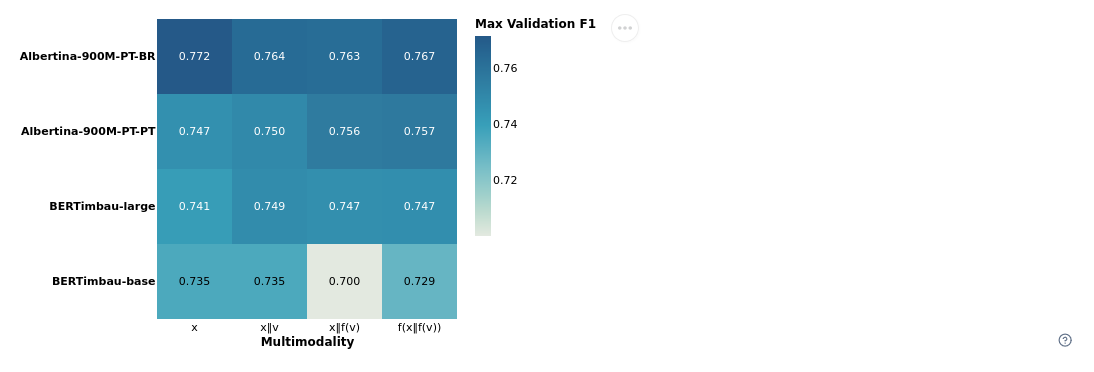

In [ ]:
_base = (
    alt.Chart(summary_df)
    .transform_aggregate(
        max_f1='max(eval/f1_macro)',
        groupby=['model', 'method']
    )
    .encode(
        alt.X('method:N')
            .sort(methods_order)
            .axis(labelAngle=0, ticks=False, domain=False)
            .title('Multimodality'),
        alt.Y('model:N')
            .sort(models_order)
            .axis(ticks=False, domain=False, labelFontWeight='bold')
            .title(None)
    )
)

_heatmap = _base.mark_rect().encode(
    color=alt.Color('max_f1:Q')
        .scale(scheme='lighttealblue')
        .title('Max Validation F1')
)

_text = _base.mark_text(baseline='middle').encode(
    text=alt.Text('max_f1:Q').format('.3f'),
    color=alt.when(alt.datum['max_f1'] >= 0.74)
        .then(alt.value("white"))
        .otherwise(alt.value("black")),
)

_g = (
    (_heatmap + _text)
    .properties(
        width=300,
        height=300
    )
)
mo.ui.altair_chart(_g)

## Sensitivity to hyperparameters

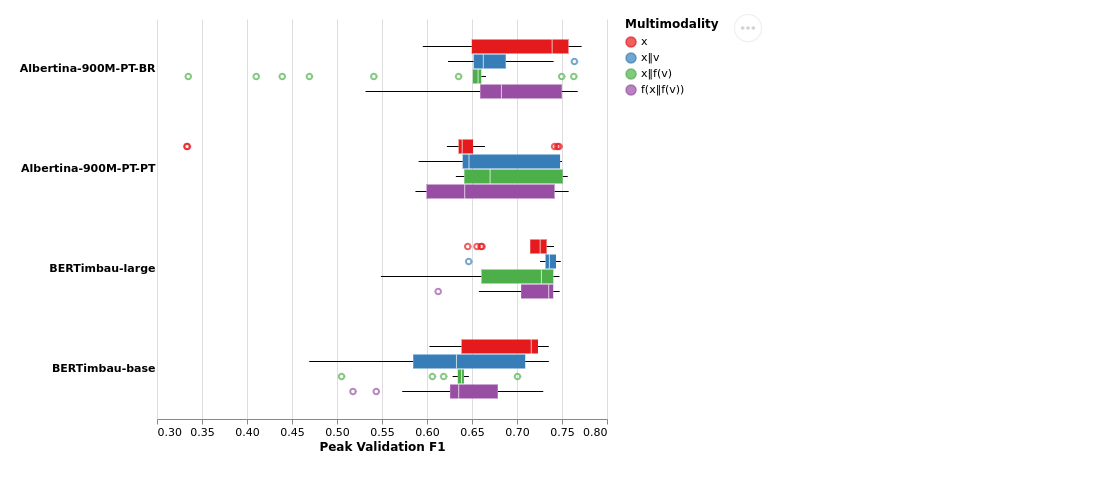

In [ ]:
_g = (
    alt.Chart(summary_df)
    .mark_boxplot()
    .encode(
        alt.X('eval/f1_macro:Q')
            .scale(zero=False)
            .title('Peak Validation F1'),
        alt.Y('model:N')
            .sort(models_order)
            .axis(domain=False, ticks=False, labelFontWeight='bold')
            .scale(paddingInner=0.4)
            .title(None),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality'),
        alt.YOffset('method:N')
            .sort(methods_order)
    )
    .properties(
        width = 450,
        height = 400
    )
)

mo.ui.altair_chart(_g)

## Training curves

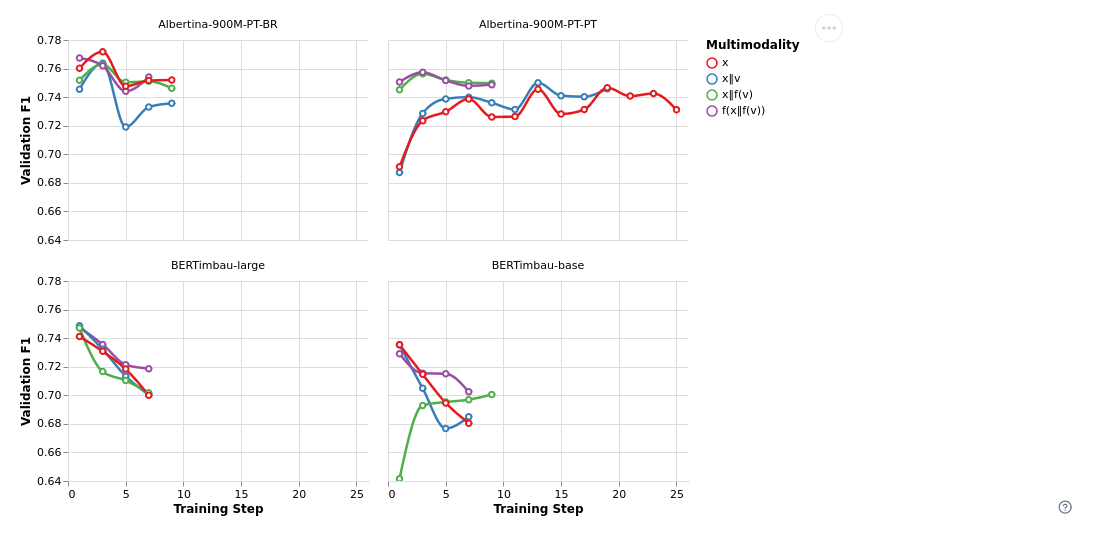

In [ ]:
_data = (
    summary_df.loc[summary_df.groupby(['model', 'method'], observed=True)['eval/f1_macro'].idxmax()]
    [['run name', 'model', 'method']]
)
_best_history = history_df[['run name', '_step', 'eval/f1_macro']].merge(_data, on='run name')
_best_history = _best_history.dropna(subset=['eval/f1_macro'])

_g = (
    alt.Chart(_best_history)
    .mark_line(
        strokeWidth=2.5,
        interpolate='monotone',
        point=alt.OverlayMarkDef(filled=False, fill='white'))
    .encode(
        alt.X('_step:Q')
            .title('Training Step'),
        alt.Y('eval/f1_macro:Q')
            .scale(zero=False)
            .title('Validation F1'),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality'),
        alt.Facet('model:N')
            .columns(2)
            .sort(models_order)
            .title(None)
    )
    .properties(
        width=300,
        height=200
    )
)

mo.ui.altair_chart(_g)

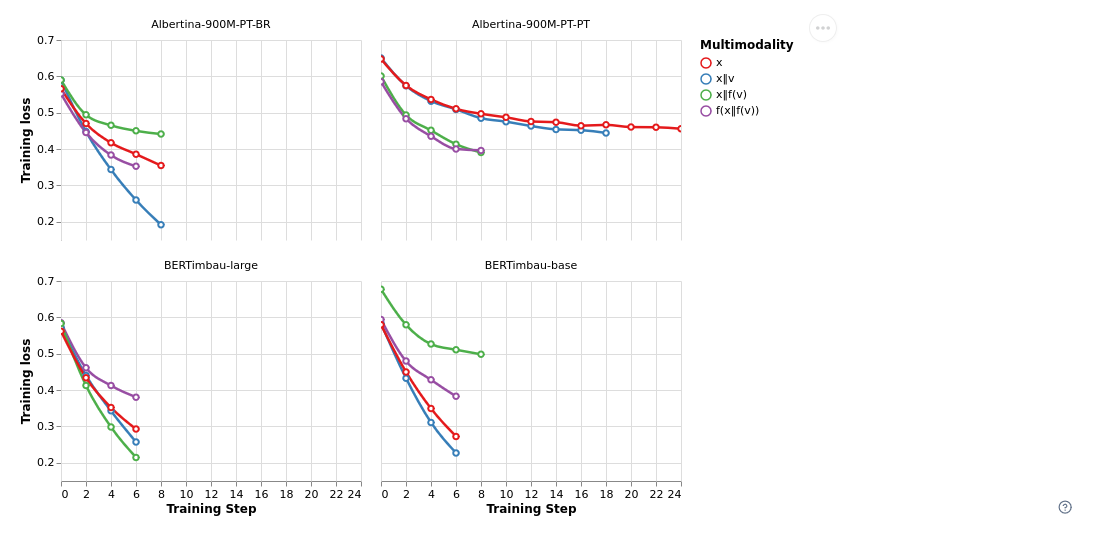

In [ ]:
_data = (
    summary_df.loc[summary_df.groupby(['model', 'method'], observed=True)['eval/f1_macro'].idxmax()]
    [['run name', 'model', 'method']]
)
_best_history = history_df[['run name', '_step', 'train/loss']].merge(_data, on='run name')
_best_history = _best_history.dropna(subset=['train/loss'])

_g = (
    alt.Chart(_best_history)
    .mark_line(
        strokeWidth=2.5,
        interpolate='monotone',
        point=alt.OverlayMarkDef(filled=False, fill='white')
    )
    .encode(
        alt.X('_step:Q')
            .title('Training Step'),
        alt.Y('train/loss:Q')
            .scale(zero=False)
            .title('Training loss'),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality'),
        alt.Facet('model:N')
            .columns(2)
            .sort(models_order)
            .title(None)
    )
    .properties(
        width=300,
        height=200
    )
)

mo.ui.altair_chart(_g)

## Best hyperparameters for each model

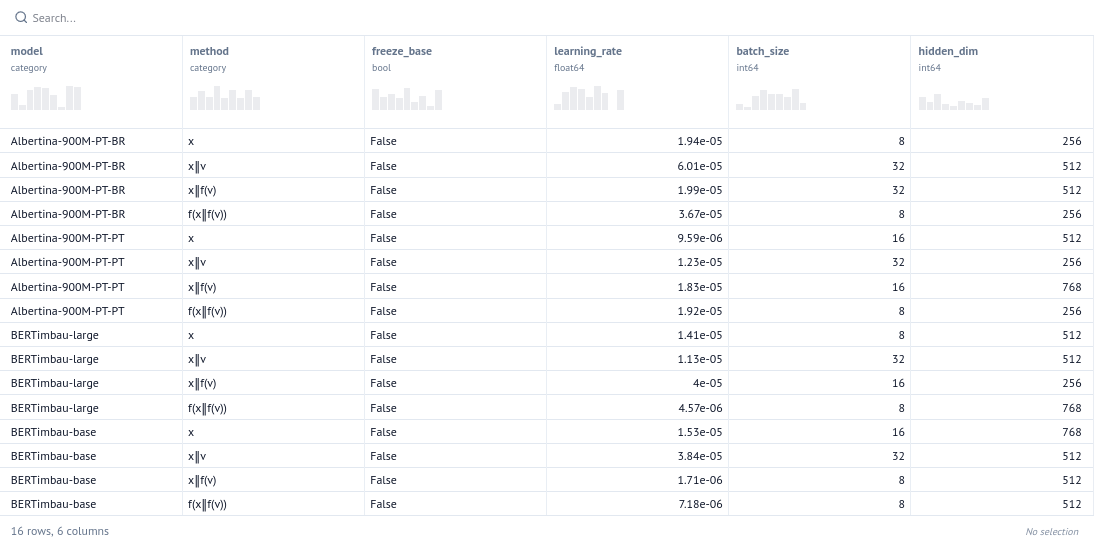

In [ ]:
mo.ui.table(
    summary_df.loc[summary_df.groupby(['model', 'method'], observed=True)['eval/f1_macro'].idxmax()]
    [['model', 'method', 'freeze_base', 'learning_rate', 'batch_size', 'hidden_dim']]
    .sort_values(['model', 'method'])
    .reset_index(drop=True),
    pagination=False,
    selection=None,
    format_mapping={
        'learning_rate': '{:.3g}'
    }
)

## Analysis for each hyperparameter

### Freeze base model

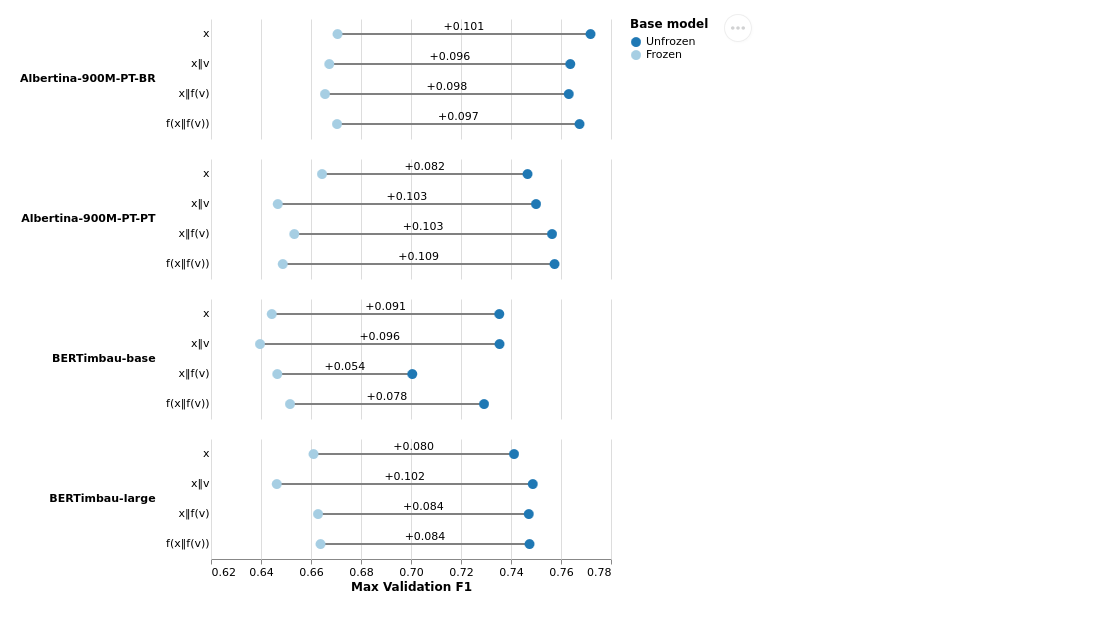

In [ ]:
_data = summary_df.groupby(['model', 'method', 'freeze_base'], as_index=False, observed=True)['eval/f1_macro'].max()
_data['freeze_base'] = _data['freeze_base'].replace({False: 'Unfrozen', True: 'Frozen'})

_pivot_data = _data.pivot(index=['model', 'method'], columns='freeze_base', values='eval/f1_macro').reset_index()
_pivot_data['delta'] = _pivot_data['Unfrozen'] - _pivot_data['Frozen']
_pivot_data['midpoint'] = (_pivot_data['Unfrozen'] + _pivot_data['Frozen']) / 2

_base = (
    alt.Chart(_pivot_data)
    .encode(
        alt.Y('method:N')
        .sort(methods_order)
        .title(None)
        .axis(domain=False, ticks=False)
    )
)

_lines = (
    _base.mark_rule(color='gray', strokeWidth=2)
        .encode(
            alt.X('Unfrozen:Q').title('Max Validation F1'),
            alt.X2('Frozen:Q')
        )
)

_text = (
    _base.mark_text(baseline='bottom', dy=-2)
    .encode(
        alt.X('midpoint:Q'),
        alt.Text('delta:Q', format='+.3f')
    )
)

_points = (
    _base.transform_fold(
        fold=['Unfrozen', 'Frozen'],
        as_=['freeze_base', 'eval/f1_macro']
    )
    .mark_circle(size=100, opacity=1)
    .encode(
        alt.Y('method:N')
            .sort(methods_order)
            .title(None)
            .axis(domain=False, ticks=False),
        alt.X('eval/f1_macro:Q').scale(zero=False),
        alt.Color('freeze_base:N')
            .scale(domain=['Unfrozen', 'Frozen'], range=['#1f78b4', '#a6cee3'])
            .title('Base model')
    )
)

_g = (
    (_lines + _text + _points)
    .properties(
        width=400,
        height=alt.Step(30)
    )
    .facet(
        row=alt.Row('model:N')
            .title(None)
            .header(labelAngle=0, labelAlign='left', labelFontWeight='bold')
    )
)

mo.ui.altair_chart(_g)

## Hidden layer dimension

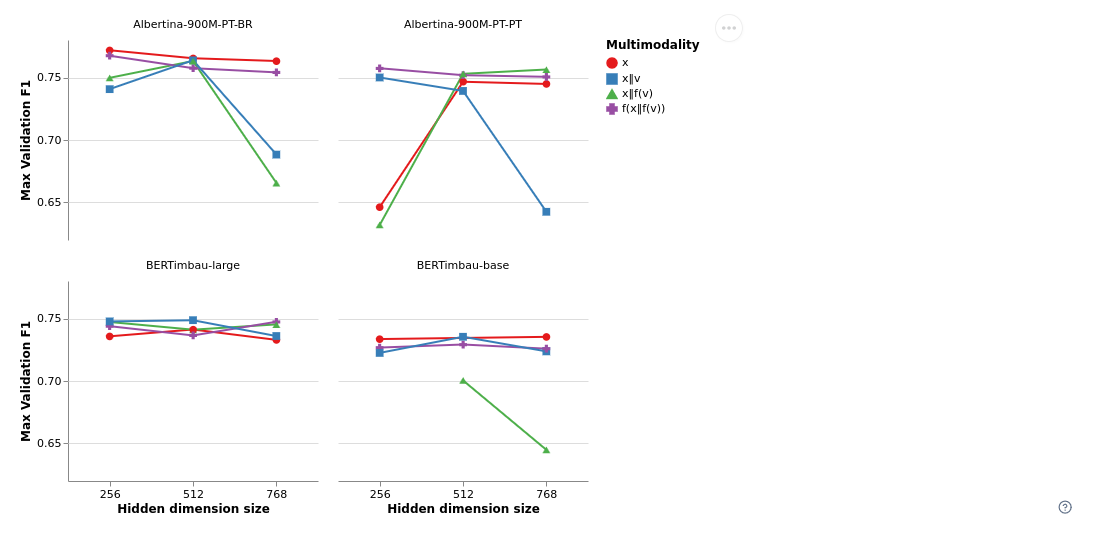

In [ ]:
_g = (
    alt.Chart(summary_df)
    .mark_line(
        point=alt.OverlayMarkDef(size=60)
    )
    .encode(
        alt.X('hidden_dim:O')
            .axis(labelAngle=0)
            .title('Hidden dimension size'),
        alt.Y('max(eval/f1_macro):Q')
            .scale(zero=False)
            .title('Max Validation F1'),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality'),
        alt.Shape('method:N')
            .sort(methods_order),
        alt.Facet('model:N')
            .columns(2)
            .sort(models_order)
            .title(None)
    )
    .properties(
        width=250,
        height=200
    )
)

mo.ui.altair_chart(_g)

## Batch size

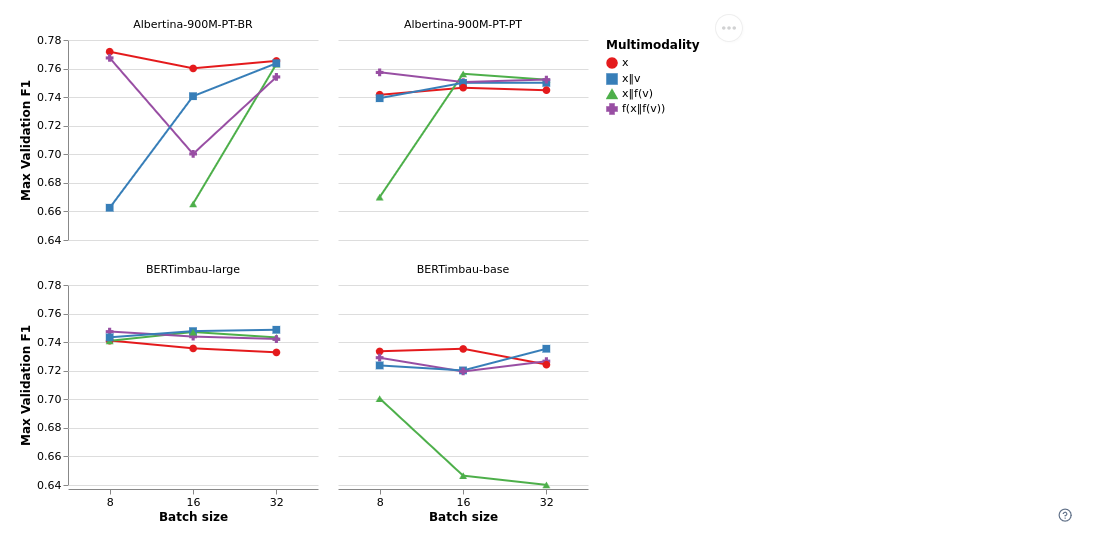

In [ ]:
_g = (
    alt.Chart(summary_df)
    .mark_line(
        point=alt.OverlayMarkDef(size=60)
    )
    .encode(
        alt.X('batch_size:O')
            .axis(labelAngle=0)
            .title('Batch size'),
        alt.Y('max(eval/f1_macro):Q')
            .scale(zero=False)
            .title('Max Validation F1'),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality'),
        alt.Shape('method:N')
            .sort(methods_order),
        alt.Facet('model:N')
            .columns(2)
            .sort(models_order)
            .title(None)
    )
    .properties(
        width=250,
        height=200
    )
)

mo.ui.altair_chart(_g)

## Learning rate

How does freezing the base model influence the learning rate?

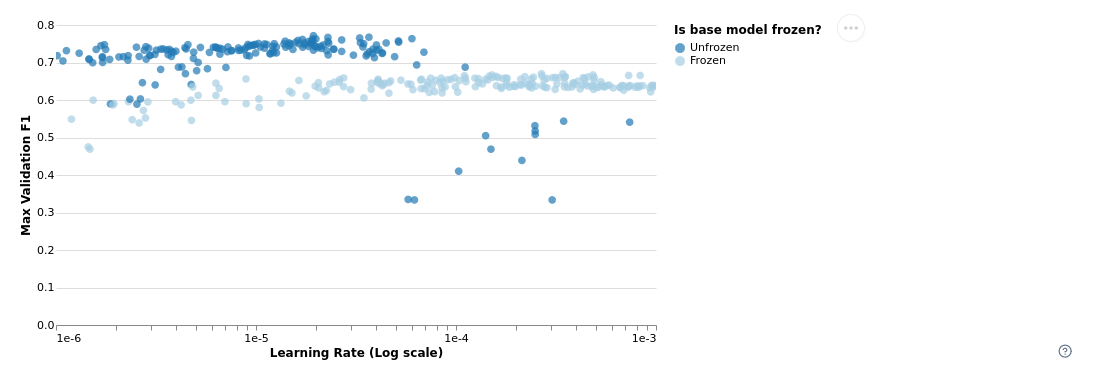

In [ ]:
_g = (
    alt.Chart(summary_df)
    .transform_calculate(
        freeze_base = 'datum.freeze_base ? "Frozen": "Unfrozen"'
    )
    .mark_circle(size=60, opacity=0.7)
    .encode(
        alt.X('learning_rate:Q')
            .axis(labelAngle=0, format='e', tickCount=5, grid=False)
            .scale(type='log')
            .title('Learning Rate (Log scale)'),
        alt.Y('eval/f1_macro:Q')
            .axis(domain=False, ticks=False)
            .title('Max Validation F1'),
        color=alt.Color('freeze_base:N')
            .scale(domain=['Unfrozen', 'Frozen'], range=['#1f78b4', '#a6cee3'])
            .title('Is base model frozen?')
    )
    .properties(
        width=600,
        height=300
    )
)
mo.ui.altair_chart(_g)

Looking only at runs with an unfrozen base model, how does the learning rate behave?

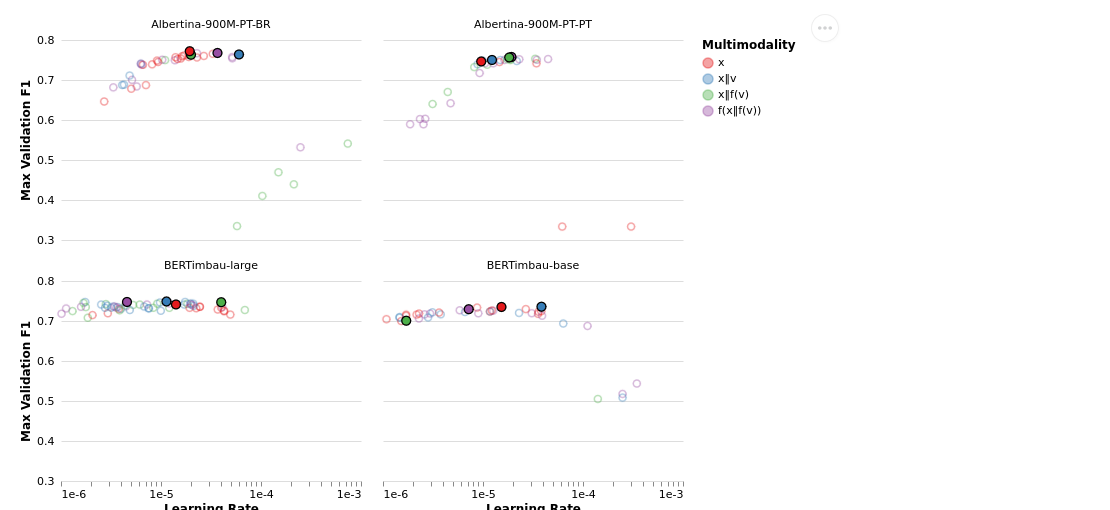

In [ ]:
_points = (
    alt.Chart(summary_df)
    .transform_filter(
        alt.datum.freeze_base == False 
    )
    .mark_point(
        size=50,
        opacity=0.4,
        strokeWidth=1.5
    )
    .encode(
        alt.X('learning_rate:Q')
              .axis(labelAngle=0, format='e', tickCount=5, grid=False)
              .scale(type='log')
              .title('Learning Rate'),
        alt.Y('eval/f1_macro:Q')
              .axis(domain=False, ticks=False)
              .scale(zero=False)
              .title('Max Validation F1'),
        alt.Color('method:N')
            .scale(scheme='set1')
            .sort(methods_order)
            .title('Multimodality')
    )
    .properties(
        width=300,
        height=200
    )
)

_best = (
    _points.transform_window(
        rank='rank()',
        sort=[alt.SortField('eval/f1_macro', order='descending')],
        groupby=['model', 'method']
    )
    .transform_filter(
        alt.datum.rank == 1
    )
    .mark_point(
        size=80,
        filled=True,
        stroke='black',
        strokeWidth=1.3,
        opacity=1
    )
)

_g = (
    (_points + _best)
     .facet(
         facet=alt.Facet('model:N', title=None).sort(models_order),
         columns=2
     )
)

mo.ui.altair_chart(_g)